#  Exploratory Data Analysis (EDA)
## Introduction
This notebook focuses on understanding the sales dataset through exploratory data analysis. The goal is to analyze patterns, trends, seasonality, and relationships within the data before applying forecasting models.
## Objective
The objective of this analysis is to identify key patterns in sales over time, detect seasonality, understand distribution characteristics, and generate insights that will help in building accurate forecasting models.

------------------------------------------------------------------------------------------------------------------------------------------------------

### Importing Required Libraries
The necessary libraries for data manipulation, visualization, and time series analysis are imported. These include pandas and numpy for data handling, matplotlib and seaborn for visualization, and statsmodels for time series decomposition and stationarity testing.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf
import warnings
warnings.filterwarnings("ignore")

### Data Loading
The dataset is loaded from a CSV file containing historical sales data along with order and customer details.

In [2]:
df = pd.read_csv(r"C:\Users\Aniket\Downloads\Capstone Projects\Sales Forecasting & Demand Prediction System\data\sales.csv")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


The dataset contains transactional-level data including order details, customer information, and sales values. Initial inspection shows a structured dataset suitable for time series analysis.

## Data Understanding
Basic structural information such as number of rows, columns, data types, and summary statistics is analyzed to understand the dataset.

In [3]:
df.shape

(9800, 18)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   str    
 2   Order Date     9800 non-null   str    
 3   Ship Date      9800 non-null   str    
 4   Ship Mode      9800 non-null   str    
 5   Customer ID    9800 non-null   str    
 6   Customer Name  9800 non-null   str    
 7   Segment        9800 non-null   str    
 8   Country        9800 non-null   str    
 9   City           9800 non-null   str    
 10  State          9800 non-null   str    
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   str    
 13  Product ID     9800 non-null   str    
 14  Category       9800 non-null   str    
 15  Sub-Category   9800 non-null   str    
 16  Product Name   9800 non-null   str    
 17  Sales          9800 non-null   float64
dtypes: float64(2), int6

In [5]:
df.describe(include="all")

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
count,9800.000000,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9789.000000,9800,9800,9800,9800,9800,9800.000000
unique,NaN,4922,1230,1326,4,793,793,3,1,529,49,NaN,4,1861,3,17,1849,NaN
top,NaN,CA-2018-100111,05/09/2017,26/09/2018,Standard Class,WB-21850,William Brown,Consumer,United States,New York City,California,NaN,West,OFF-PA-10001970,Office Supplies,Binders,Staple envelope,NaN
freq,NaN,14,38,34,5859,35,35,5101,9800,891,1946,NaN,3140,19,5909,1492,47,NaN
mean,4900.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,55273.322403,NaN,NaN,NaN,NaN,NaN,230.769059
std,2829.160653,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,32041.223413,NaN,NaN,NaN,NaN,NaN,626.651875
min,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1040.000000,NaN,NaN,NaN,NaN,NaN,0.444000
25%,2450.750000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23223.000000,NaN,NaN,NaN,NaN,NaN,17.248000
50%,4900.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,58103.000000,NaN,NaN,NaN,NaN,NaN,54.490000
75%,7350.250000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,90008.000000,NaN,NaN,NaN,NaN,NaN,210.605000


The dataset consists of thousands of records with multiple categorical and numerical features, indicating a rich transactional dataset. Most columns are categorical, while sales is the primary numerical variable. The presence of missing values in postal code suggests minor data quality issues, but overall the dataset is clean and usable.

## Data Cleaning
Irrelevant columns are removed and date columns are converted into proper datetime format to enable time-based analysis.

In [6]:
df.drop("Row ID",axis=1,inplace=True)

In [7]:
df["Order Date"] = pd.to_datetime(df["Order Date"],dayfirst=True)
df["Ship Date"] = pd.to_datetime(df["Ship Date"],dayfirst=True)

The conversion of date columns ensures that time-based operations such as aggregation, trend analysis, and feature extraction can be performed efficiently.

## Missing Value Handling
Checking for null values in the dataset.

In [8]:
df.isnull().sum()

Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

In [9]:
df.dropna(inplace=True)

In [10]:
df.isnull().sum()

Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
dtype: int64

The dataset contains very few missing values, which are handled by dropping affected rows. This ensures that the analysis is not biased due to incomplete data.

## Handlling Duplicates
checking for duplicates in the data

In [11]:
df.duplicated().sum()

np.int64(1)

In [12]:
df.drop_duplicates(inplace=True)

The dataset contains only one duplicate and we drop it.

In [13]:
df.shape

(9788, 17)

## Time Series Aggregation
Sales data is aggregated at a daily level to analyze trends over time.

In [14]:
df_daily = df.groupby("Order Date")["Sales"].sum().reset_index()
df_daily.rename(columns={"Order Date" : "Date"},inplace=True)
df_daily.head()

,Date,Sales
0,2015-01-03,16.448
1,2015-01-04,288.060
2,2015-01-05,19.536
3,2015-01-06,4407.100
4,2015-01-07,87.158


Aggregating the data at daily level simplifies the dataset and makes it suitable for time series analysis, enabling better visualization of trends and patterns.

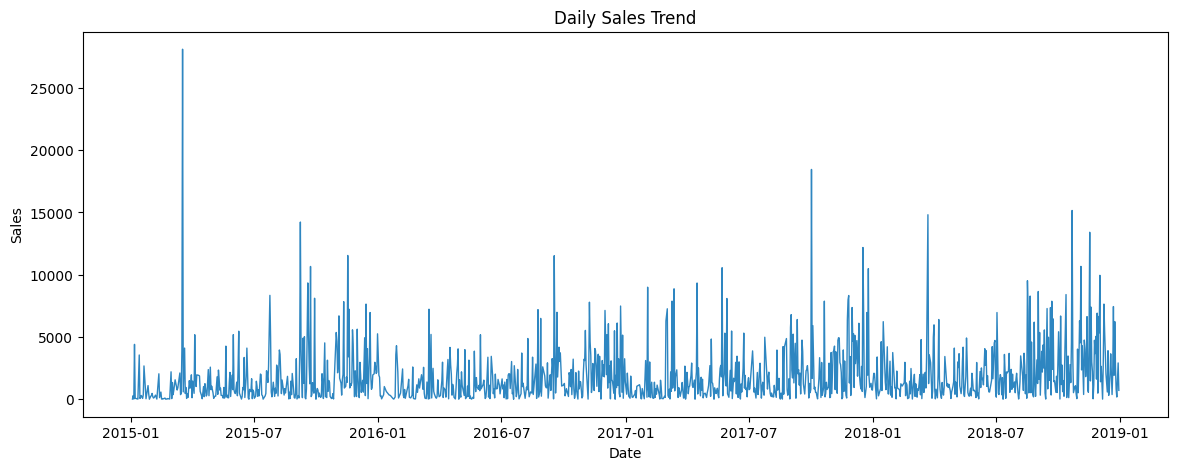

In [15]:
plt.figure(figsize=(14,5))
plt.plot(df_daily["Date"],df_daily["Sales"],color="#2E86C1", linewidth=1)
plt.title("Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

#### Daily Sales Trend (Insights) :

This graph shows how sales vary over time.
The daily sales trend shows highly fluctuating behavior with multiple sharp spikes, indicating irregular demand patterns and the presence of extreme values or bulk orders. There is no smooth pattern, suggesting that sales are volatile and influenced by external factors such as promotions or seasonal demand.

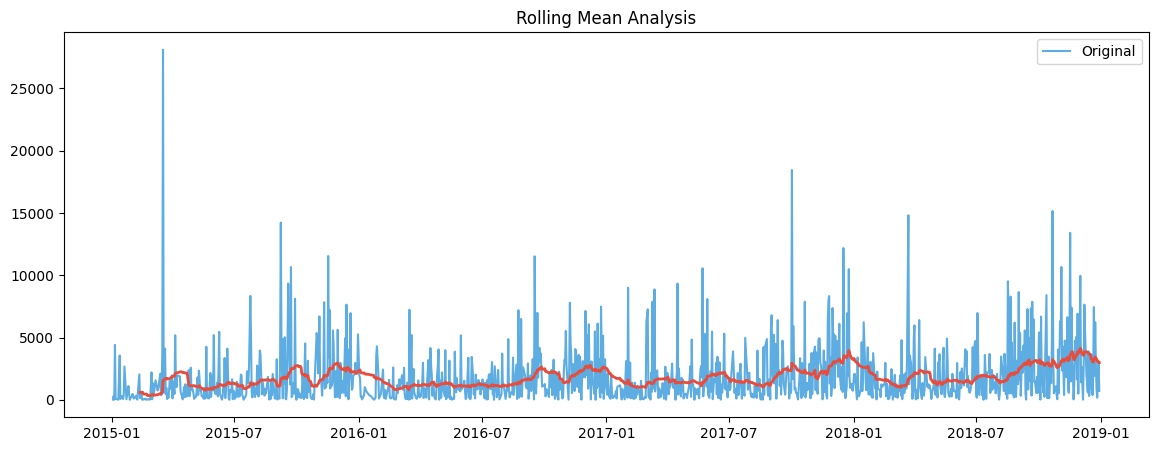

In [16]:
df_daily["rolling_mean"] = df_daily["Sales"].rolling(window=30).mean()
df_daily["rolling_std"] = df_daily["Sales"].rolling(window=30).std()

plt.figure(figsize=(14,5))
plt.plot(df_daily["Date"],df_daily["Sales"],label="Original",color="#5DADE2")
plt.plot(df_daily["Date"],df_daily["rolling_mean"],color="#E74C3C", linewidth=2)
plt.legend()
plt.title("Rolling Mean Analysis")
plt.show()

#### Rolling Mean Analysis (Insights) :
This graph smooths the sales data to identify underlying trends.
The rolling mean line smooths out short-term fluctuations and reveals a gradual upward trend in sales over time, indicating overall business growth despite daily volatility.

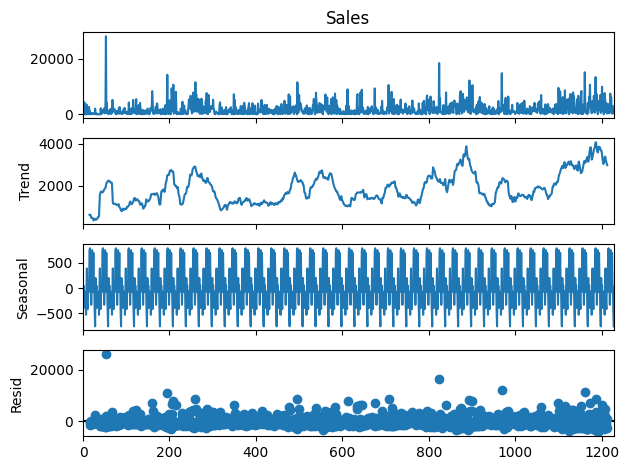

In [17]:
decomposition = seasonal_decompose(df_daily["Sales"],model="additive",period=30)
decomposition.plot()
plt.show()

#### Seasonal Decomposition (Insights) :

The time series is decomposed into trend, seasonal, and residual components.
The decomposition shows a clear upward trend component, while the seasonal component exhibits repeating patterns, indicating periodic behavior in sales. The residual component contains noise and irregular fluctuations, suggesting that not all variations are explained by trend or seasonality.

In [18]:
result = adfuller(df_daily["Sales"])
print("ADF Statistic:",result[0])
print("p-value:",result[1])

ADF Statistic: -5.712438067892147
p-value: 7.247541649176822e-07


#### Stationarity Test (ADF Test)
The Augmented Dickey-Fuller test is used to check whether the time series is stationary.
The very low p-value indicates that the null hypothesis of non-stationarity is rejected, meaning the time series is stationary and suitable for modeling without heavy differencing.

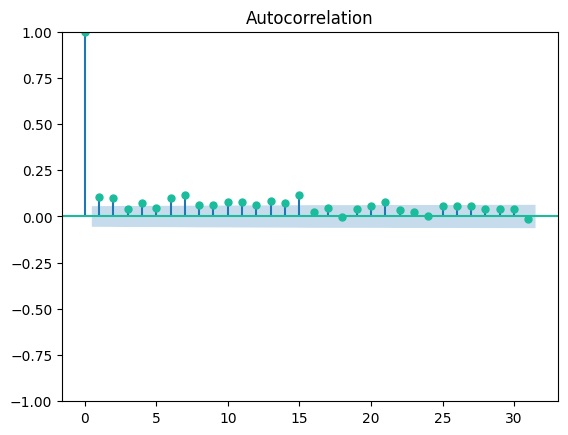

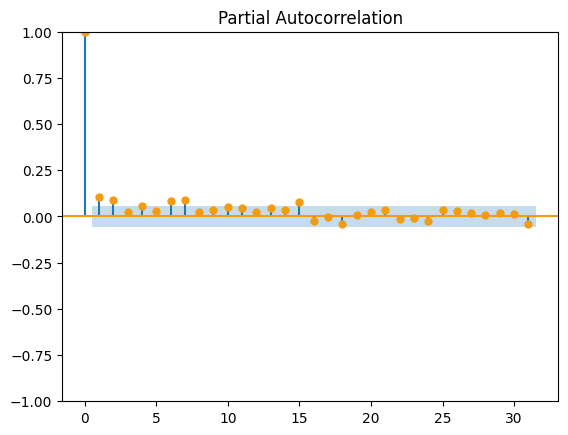

In [19]:
plot_acf(df_daily["Sales"],color="#1ABC9C")
plt.show()

plot_pacf(df_daily["Sales"],color="#F39C12")
plt.show()

#### Autocorrelation Analysis (Insights) :
ACF and PACF plots help identify lag relationships in the data.
The ACF plot shows that sales have a strong correlation at initial lags which gradually decreases, while the PACF indicates that only a few lag values significantly influence the series, suggesting that past sales values play an important role in predicting future sales.

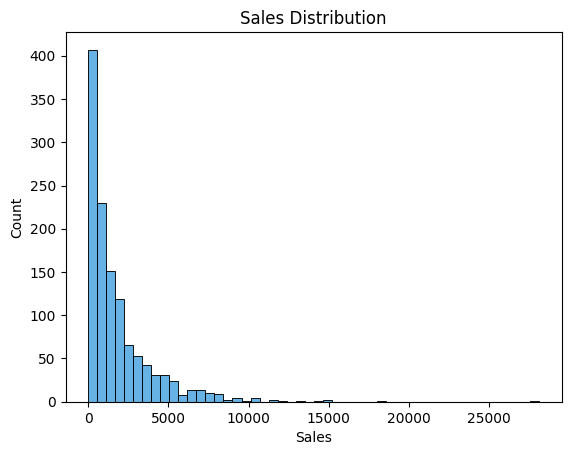

In [20]:
sns.histplot(df_daily["Sales"], bins=50, color="#3498DB")
plt.title("Sales Distribution")
plt.show()

#### Sales Distribution (Insights) :

Distribution of sales values is analyzed.
The distribution is highly right-skewed, indicating that most sales values are low while a few extreme values dominate, which can negatively impact model performance if not transformed.

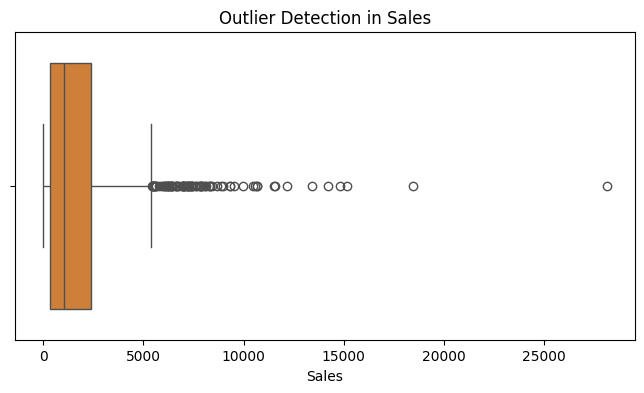

In [21]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df_daily["Sales"],color="#E67E22")
plt.title("Outlier Detection in Sales")
plt.show()

#### Outlier Detection in Sales (Insights):
A boxplot is used to identify extreme values (outliers) in the sales data.The boxplot clearly shows the presence of a large number of extreme values in the sales data, with several points lying far beyond the upper whisker, indicating strong positive outliers. This confirms that the dataset is highly skewed and dominated by occasional large transactions, which can significantly impact model performance if not handled properly.These outliers suggest that transformation techniques such as log transformation are necessary.

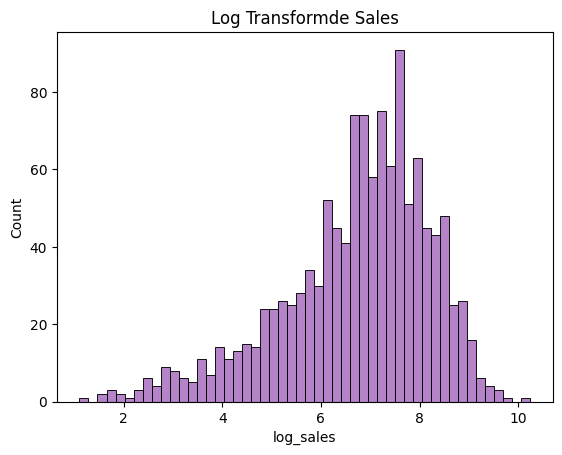

In [22]:
df_daily["log_sales"] = np.log1p(df_daily["Sales"])
sns.histplot(df_daily["log_sales"], bins=50, color="#9B59B6")
plt.title("Log Transformde Sales")
plt.show()

#### Log Transformation (Insights) :
Log transformation is applied to reduce skewness.
After log transformation, the distribution becomes more symmetric and closer to normal, making it more suitable for machine learning models.

In [23]:
df_daily["year"] = df_daily["Date"].dt.year
df_daily["month"] = df_daily["Date"].dt.month
df_daily["dayofweek"] = df_daily["Date"].dt.dayofweek

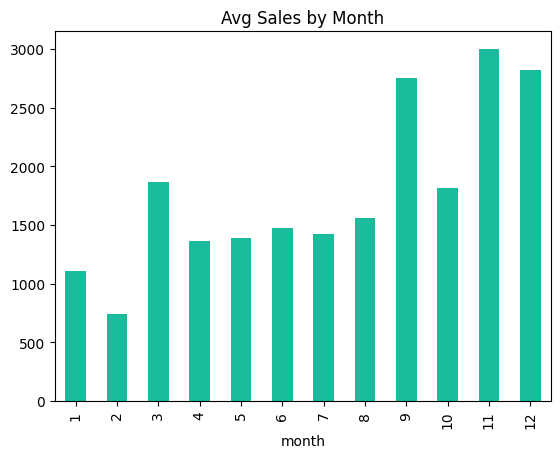

In [24]:
df_daily.groupby("month")["Sales"].mean().plot(kind="bar",color="#1ABC9C",title="Avg Sales by Month")
plt.show()

#### Monthly Sales Analysis (Insights) :
Average sales across different months are analyzed.
Sales tend to increase towards the end of the year, especially during the last quarter, indicating strong seasonal demand likely driven by festive periods or year-end purchasing behavior.

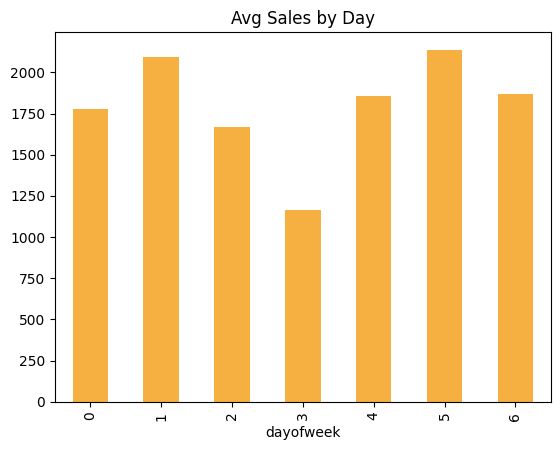

In [25]:
df_daily.groupby("dayofweek")["Sales"].mean().plot(kind="bar",color="#F5B041",title="Avg Sales by Day")
plt.show()

#### Daily Sales Analysis (Insights) :
Sales vary across different days of the week, with certain days showing higher average sales, indicating that customer purchasing behavior is influenced by weekday patterns.

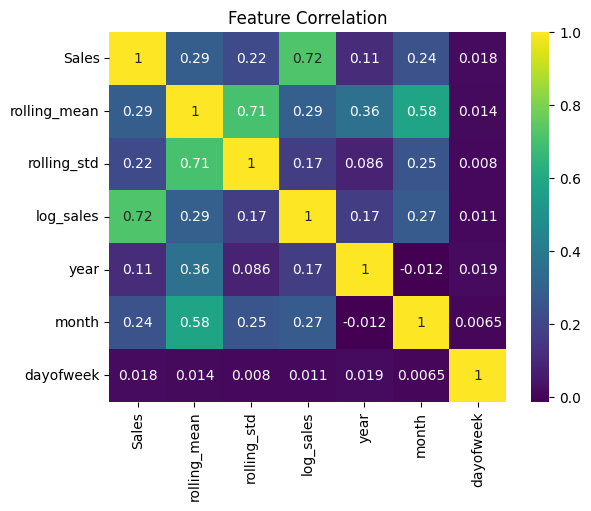

In [26]:
df_corr = df_daily.drop(columns=["Date"])
sns.heatmap(df_corr.corr(), annot=True, cmap="viridis")
plt.title("Feature Correlation")
plt.show()

#### Feature Correlation (Insights) :
Correlation between different features is analyzed.
Sales shows a strong relationship with log_sales and moderate relationships with rolling statistics, indicating that past trends and transformations are useful predictors, while features like dayofweek have very weak correlation with sales.

### Saving Processed Data
The processed dataset is saved for further modeling.

In [27]:
df_daily.to_csv("df_daily.csv",index=False)

The cleaned and feature-enhanced dataset is saved as a CSV file to be used in the modeling phase, ensuring consistency across different stages of the project.

## Conclusion
The exploratory data analysis reveals that the sales data exhibits high volatility with clear trends and seasonal patterns. The presence of skewness in sales distribution required transformation, while time-based features such as month and rolling averages provide valuable predictive signals. These insights form a strong foundation for building accurate forecasting models in the next stage.